In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os


In [2]:
# MNIST
gradient_computation=[16.300145149230957, 15.085385084152222, 16.704367637634277, 16.358423233032227]
cplex_computation=[28.519342184066772, 32.15989422798157, 47.0468533039093, 52.49611735343933]
model_training=[6.967055559158325, 5.91877293586731, 5.253190994262695, 6.094507694244385]

MNIST = [np.sum(model_training), np.sum(cplex_computation), np.sum(gradient_computation)]

# BiasedMNIST EO
gradient_computation=[58.71622085571289, 52.00600600242615, 55.37805366516113, 53.99328136444092]
cplex_computation=[93.71936750411987, 104.14960432052612, 150.80583310127258, 167.91209983825684]
model_training=[18.359981536865234, 21.373514890670776, 18.477519273757935, 30.60397982597351]

BiasedMNIST_EO = [np.sum(model_training), np.sum(cplex_computation), np.sum(gradient_computation)]

# BiasedMNIST DP
gradient_computation=[58.01699876785278, 50.164067029953, 51.49315094947815, 51.52335786819458]
cplex_computation=[86.37766695022583, 100.67694330215454, 141.92226386070251, 157.2609670162201]
model_training=[18.49573540687561, 20.66844081878662, 15.707951307296753, 18.20212483406067]

BiasedMNIST_DP = [np.sum(model_training), np.sum(cplex_computation), np.sum(gradient_computation)]


In [3]:
runtimes = [MNIST, BiasedMNIST_EO, BiasedMNIST_DP]
x = ["MNIST - EER", "Biased MNIST - EO", "Biased MNIST - DP"]
runtime_dict = dict(zip(x, runtimes))
labels = ["Model Training", "CPLEX Computation", "Gradient Computation"]

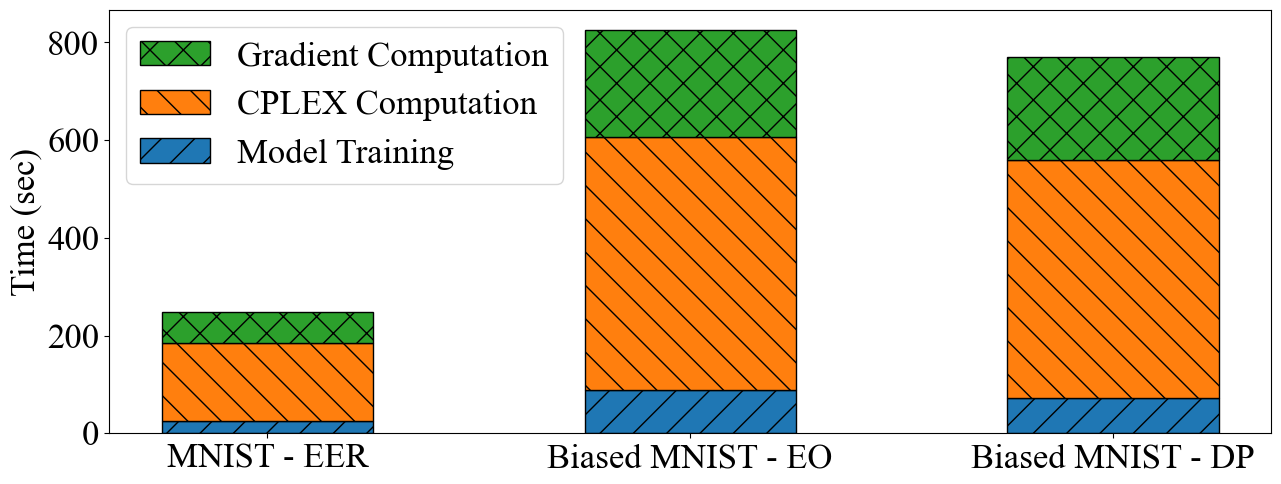

In [4]:
# MNIST / FashionMNIST
hatch_patterns = ['/', '\\', 'x']

plt.figure(figsize=(15, 5.5))
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['pdf.fonttype'] = 42    
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rc('xtick', labelsize=25)
plt.rc('ytick', labelsize=25)
plt.rc('legend', fontsize=25)
plt.rc('figure', titlesize=25)
prev_y = np.zeros(len(x))
for i, l in enumerate(labels):
    y = np.array([r[i] for r in runtimes])
    y+=prev_y
    plt.bar(x, [r[i] for r in runtimes], bottom=prev_y, edgecolor='black', width = 0.5, label=labels[i], hatch = hatch_patterns[i])
    prev_y = y

# plt.ylim(900)
plt.ylabel('Time (sec)')


# Get the handles and labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse the order of handles and labels
handles, labels = reversed(handles), reversed(labels)

plt.legend(handles, labels, loc='upper left')

plt.savefig(f"overall_runtime.pdf", bbox_inches="tight")


